In [7]:
import os
from glob import glob
from tqdm import tqdm

import cv2
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline
plt.ion()   # interactive mode

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.autograd import Variable
import torchvision
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset

# sklearn libraries
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [56]:
import zipfile
import shutil

# Define the target directory path that the original notebook expects
target_dir = '../input/skin-cancer-mnist-ham10000'
data_source_dir = '/content/sample_data'

# Create the target directory and its parent if they don't exist
os.makedirs(target_dir, exist_ok=True)

# List of image zip files to extract
zip_files = ['HAM10000_images_part_1.zip', 'HAM10000_images_part_2.zip']

# Extract each zip file into the target directory
for zip_file_name in zip_files:
    zip_path = os.path.join(data_source_dir, zip_file_name)
    if os.path.exists(zip_path):
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(target_dir)
        print(f"Extracted {zip_file_name} to {target_dir}")
    else:
        print(f"Warning: {zip_path} not found. Please ensure all data files are in {data_source_dir}.")

# Handle the metadata file:
# The kernel state shows 'HAM10000_metadata' without '.csv' extension in sample_data.
# The notebook code in subsequent cells expects 'HAM10000_metadata.csv'.
# We will copy it to the target directory and rename it if necessary.
metadata_source_path = os.path.join(data_source_dir, 'HAM10000_metadata')
metadata_target_path = os.path.join(target_dir, 'HAM10000_metadata.csv')

if os.path.exists(metadata_source_path) and os.path.isfile(metadata_source_path):
    shutil.copy(metadata_source_path, metadata_target_path)
    print(f"Copied metadata from {metadata_source_path} to {metadata_target_path}")
elif os.path.exists(os.path.join(data_source_dir, 'HAM10000_metadata.csv')):
    # If it was already named .csv in sample_data, copy it
    shutil.copy(os.path.join(data_source_dir, 'HAM10000_metadata.csv'), metadata_target_path)
    print(f"Copied metadata from {os.path.join(data_source_dir, 'HAM10000_metadata.csv')} to {metadata_target_path}")
else:
    print(f"Warning: 'HAM10000_metadata' or 'HAM10000_metadata.csv' not found in {data_source_dir}. Please ensure the metadata file is present.")

# Now, execute the original command to list the contents of the prepared directory
os.listdir(target_dir)


Extracted HAM10000_images_part_1.zip to ../input/skin-cancer-mnist-ham10000
Extracted HAM10000_images_part_2.zip to ../input/skin-cancer-mnist-ham10000
Copied metadata from /content/sample_data/HAM10000_metadata to ../input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv


['ISIC_0025300.jpg',
 'ISIC_0030298.jpg',
 'ISIC_0025526.jpg',
 'ISIC_0027693.jpg',
 'ISIC_0026715.jpg',
 'ISIC_0024525.jpg',
 'ISIC_0027006.jpg',
 'ISIC_0025510.jpg',
 'ISIC_0028735.jpg',
 'ISIC_0032762.jpg',
 'ISIC_0026055.jpg',
 'ISIC_0030755.jpg',
 'ISIC_0026578.jpg',
 'ISIC_0025504.jpg',
 'ISIC_0031166.jpg',
 'ISIC_0031975.jpg',
 'ISIC_0034042.jpg',
 'ISIC_0033775.jpg',
 'ISIC_0028210.jpg',
 'ISIC_0028854.jpg',
 'ISIC_0028938.jpg',
 'ISIC_0025962.jpg',
 'ISIC_0025933.jpg',
 'ISIC_0029219.jpg',
 'ISIC_0029370.jpg',
 'ISIC_0030623.jpg',
 'ISIC_0033614.jpg',
 'ISIC_0032013.jpg',
 'ISIC_0030414.jpg',
 'ISIC_0025458.jpg',
 'ISIC_0026764.jpg',
 'ISIC_0025606.jpg',
 'ISIC_0027154.jpg',
 'ISIC_0033812.jpg',
 'ISIC_0030397.jpg',
 'ISIC_0025168.jpg',
 'ISIC_0026116.jpg',
 'ISIC_0027615.jpg',
 'ISIC_0029863.jpg',
 'ISIC_0029348.jpg',
 'ISIC_0029943.jpg',
 'ISIC_0031084.jpg',
 'ISIC_0024381.jpg',
 'ISIC_0033310.jpg',
 'ISIC_0025166.jpg',
 'ISIC_0032646.jpg',
 'ISIC_0029730.jpg',
 'ISIC_002931

In [57]:
df_metadata = pd.read_csv(os.path.join(target_dir, 'HAM10000_metadata.csv'))
display(df_metadata.head())

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern


In [58]:
base_dir = os.path.join('..', 'input','skin-cancer-mnist-ham10000' )
all_image_path = glob(os.path.join(base_dir, '*.jpg')) # Corrected glob pattern
imageid_path_dict = {os.path.splitext(os.path.basename(x))[0]: x for x in all_image_path}
lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'dermatofibroma',
    'bkl': 'Benign keratosis-like lesions ',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

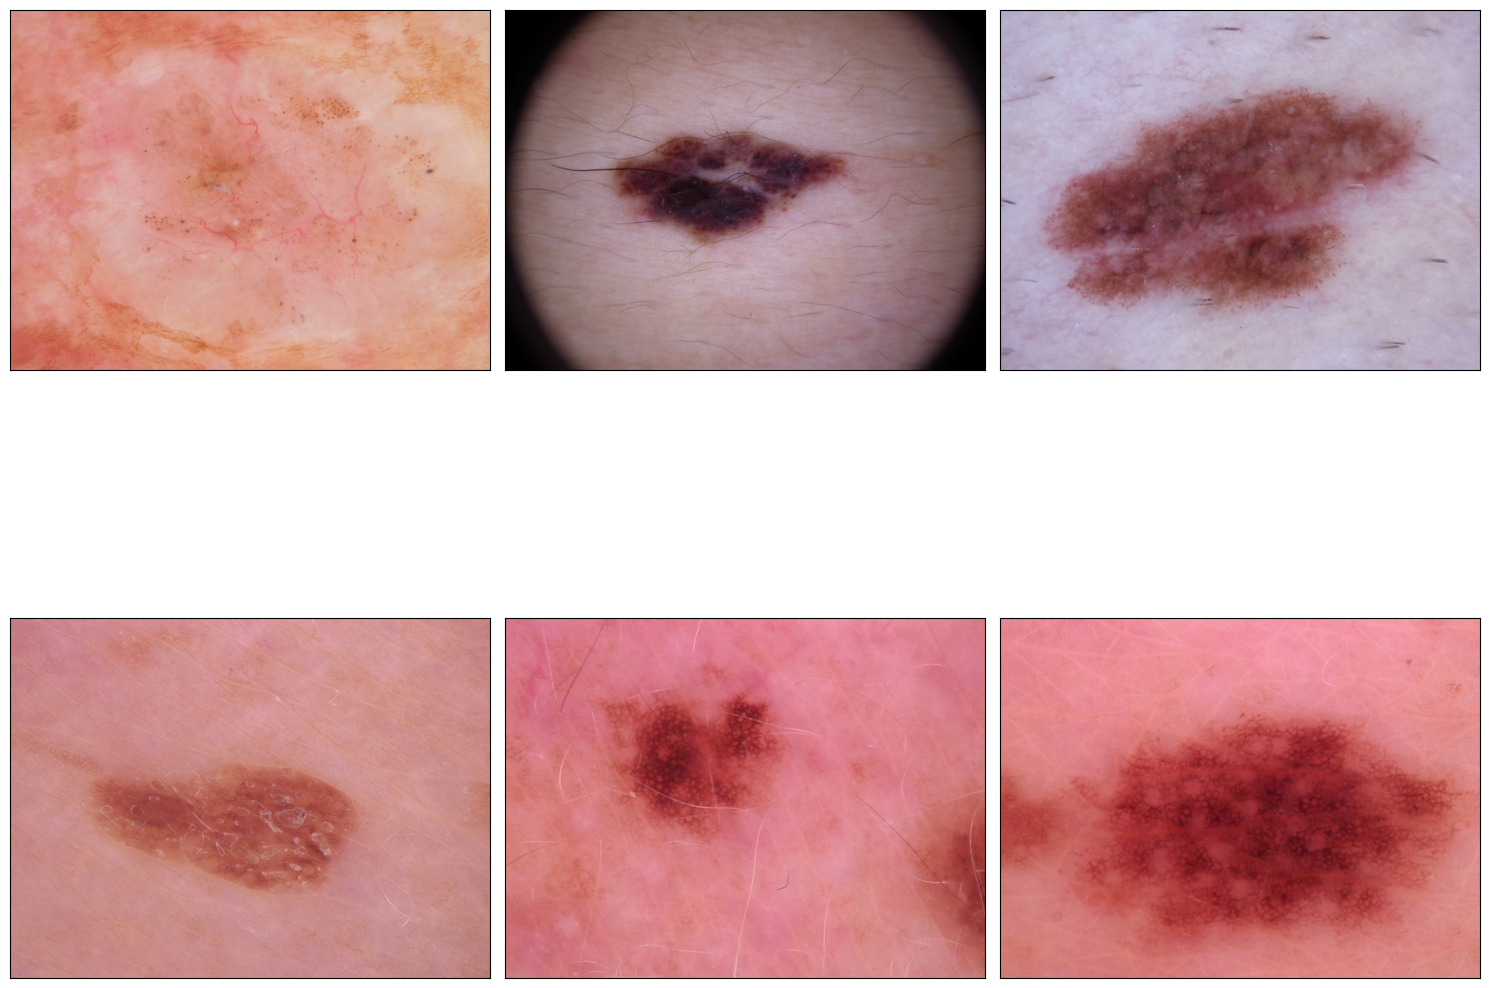

In [59]:
w, h = 10, 10
fig = plt.figure(figsize=(15, 15))
columns, rows = 3, 2
start, end = 0, len(imageid_path_dict)
ax = []
import random
for i in range(columns*rows):
    k = random.randint(start, end)
    img = mpimg.imread((all_image_path[k]))
#     title = (train_df.iloc[k,0]).split('/')
#     title = title[2]+'-'+title[3]+'-'+title[4]
#     k += 1
    # create subplot and append to ax
    ax.append( fig.add_subplot(rows, columns, i+1) )
#     ax[-1].set_title(title)  # set title
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img, cmap="gray")
plt.tight_layout()
plt.show()  # finally, render the plot

In [60]:
# Checking the size and number of channels in the image
arr = np.asarray(Image.open(all_image_path[48]))
arr.shape

(450, 600, 3)

In [61]:
df_original = pd.read_csv(os.path.join(base_dir, 'HAM10000_metadata.csv'))
df_original['path'] = df_original['image_id'].map(imageid_path_dict.get)
df_original['cell_type'] = df_original['dx'].map(lesion_type_dict.get)
df_original['cell_type_idx'] = pd.Categorical(df_original['cell_type']).codes
df_original.head()


,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,path,cell_type,cell_type_idx
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern,../input/skin-cancer-mnist-ham10000/ISIC_00274...,Benign keratosis-like lesions,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern,../input/skin-cancer-mnist-ham10000/ISIC_00250...,Benign keratosis-like lesions,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern,../input/skin-cancer-mnist-ham10000/ISIC_00267...,Benign keratosis-like lesions,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern,../input/skin-cancer-mnist-ham10000/ISIC_00256...,Benign keratosis-like lesions,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern,../input/skin-cancer-mnist-ham10000/ISIC_00316...,Benign keratosis-like lesions,2


Dx is short for diagnosis (for the patient) and dx_type is how the diagnosis was made.
A bit more about each type of diagnosis and how they were made is available in the original paper https://arxiv.org/abs/1803.10417

In [62]:
df_original[['cell_type_idx', 'cell_type']].sort_values('cell_type_idx').drop_duplicates()

,cell_type_idx,cell_type
9804,0,Actinic keratoses
2528,1,Basal cell carcinoma
1018,2,Benign keratosis-like lesions
1159,3,Dermatofibroma
7050,4,Melanocytic nevi
2370,5,Vascular lesions
1577,6,dermatofibroma


In the table above we have a nice overview of our groundtruth data. What we care for is only the column 'cell_type_idx', because these values are needed for the model training.
But of course it is nice to know what these labels mean, that is what the column 'cell_type' is for. Lets quickly check how often the different tumors occur in our dataset:

In [63]:
df_original['cell_type'].value_counts()


,count
cell_type,
Melanocytic nevi,6705
dermatofibroma,1113
Benign keratosis-like lesions,1099
Basal cell carcinoma,514
Actinic keratoses,327
Vascular lesions,142
Dermatofibroma,115


In [64]:
def compute_img_mean_std(image_paths):
    """
        computing the mean and std of three channel on the whole dataset,
        first we should normalize the image from 0-255 to 0-1
    """

    img_h, img_w = 224, 224
    imgs = []
    means, stdevs = [], []

    for i in tqdm(range(len(image_paths))):
        img = cv2.imread(image_paths[i])
        img = cv2.resize(img, (img_h, img_w))
        imgs.append(img)

    imgs = np.stack(imgs, axis=3)
    print(imgs.shape)

    imgs = imgs.astype(np.float32) / 255.

    for i in range(3):
        pixels = imgs[:, :, i, :].ravel()  # resize to one row
        means.append(np.mean(pixels))
        stdevs.append(np.std(pixels))

    means.reverse()  # BGR --> RGB
    stdevs.reverse()

    print("normMean = {}".format(means))
    print("normStd = {}".format(stdevs))
    return means,stdevs

In [65]:
# norm_mean,norm_std = compute_img_mean_std(all_image_path)

In [66]:
normMean = [0.7630358, 0.54564357, 0.5700475]
normStd = [0.14092763, 0.15261263, 0.16997081]
# for future reference

In [67]:
# this will tell us how many images are associated with each lesion_id
df_undup = df_original.groupby('lesion_id').count()
# now we filter out lesion_id's that have only one image associated with it
df_undup = df_undup[df_undup['image_id'] == 1]
df_undup.reset_index(inplace=True)
df_undup.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,path,cell_type,cell_type_idx
0,HAM_0000001,1,1,1,1,1,1,1,1,1,1
1,HAM_0000003,1,1,1,1,1,1,1,1,1,1
2,HAM_0000004,1,1,1,1,1,1,1,1,1,1
3,HAM_0000007,1,1,1,1,1,1,1,1,1,1
4,HAM_0000008,1,1,1,1,1,1,1,1,1,1


In [68]:
# here we identify lesion_id's that have duplicate images and those that have only one image.
def get_duplicates(x):
    unique_list = list(df_undup['lesion_id'])
    if x in unique_list:
        return 'unduplicated'
    else:
        return 'duplicated'

# create a new colum that is a copy of the lesion_id column
df_original['duplicates'] = df_original['lesion_id']
# apply the function to this new column
df_original['duplicates'] = df_original['duplicates'].apply(get_duplicates)
df_original.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,path,cell_type,cell_type_idx,duplicates
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern,../input/skin-cancer-mnist-ham10000/ISIC_00274...,Benign keratosis-like lesions,2,duplicated
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern,../input/skin-cancer-mnist-ham10000/ISIC_00250...,Benign keratosis-like lesions,2,duplicated
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern,../input/skin-cancer-mnist-ham10000/ISIC_00267...,Benign keratosis-like lesions,2,duplicated
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern,../input/skin-cancer-mnist-ham10000/ISIC_00256...,Benign keratosis-like lesions,2,duplicated
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern,../input/skin-cancer-mnist-ham10000/ISIC_00316...,Benign keratosis-like lesions,2,duplicated


In [69]:
df_original['duplicates'].value_counts()

,count
duplicates,
unduplicated,5514
duplicated,4501


In [70]:
# now we filter out images that don't have duplicates
df_undup = df_original[df_original['duplicates'] == 'unduplicated']
df_undup.shape

(5514, 12)

In [71]:
# now we create a val set using df because we are sure that none of these images have augmented duplicates in the train set
y = df_undup['cell_type_idx']
_, df_val = train_test_split(df_undup, test_size=0.2, random_state=101, stratify=y)
df_val.shape

(1103, 12)

In [72]:
df_val['cell_type_idx'].value_counts()

,count
cell_type_idx,
4,883
2,88
6,46
1,35
0,30
5,13
3,8


In [73]:
# This set will be df_original excluding all rows that are in the val set
# This function identifies if an image is part of the train or val set.
def get_val_rows(x):
    # create a list of all the lesion_id's in the val set
    val_list = list(df_val['image_id'])
    if str(x) in val_list:
        return 'val'
    else:
        return 'train'

# identify train and val rows
# create a new colum that is a copy of the image_id column
df_original['train_or_val'] = df_original['image_id']
# apply the function to this new column
df_original['train_or_val'] = df_original['train_or_val'].apply(get_val_rows)
# filter out train rows
df_train = df_original[df_original['train_or_val'] == 'train']
print(len(df_train))
print(len(df_val))


8912
1103


In [74]:
df_train['cell_type'].value_counts()

,count
cell_type,
Melanocytic nevi,5822
dermatofibroma,1067
Benign keratosis-like lesions,1011
Basal cell carcinoma,479
Actinic keratoses,297
Vascular lesions,129
Dermatofibroma,107


In [75]:
df_val['cell_type'].value_counts()


,count
cell_type,
Melanocytic nevi,883
Benign keratosis-like lesions,88
dermatofibroma,46
Basal cell carcinoma,35
Actinic keratoses,30
Vascular lesions,13
Dermatofibroma,8


From From the above statistics of each category, we can see that there is a serious class imbalance in the training data. To solve this problem, I think we can start from two aspects, one is equalization sampling, and the other is a loss function that can be used to mitigate category imbalance during training, such as focal loss.

In [76]:
# Copy fewer class to balance the number of 7 classes
data_aug_rate = [15,10,5,50,0,40,5]
for i in range(7):
    if data_aug_rate[i]:
        df_train=pd.concat([df_train] + [df_train.loc[df_train['cell_type_idx'] == i,:]]*(data_aug_rate[i]-1), ignore_index=True)
df_train['cell_type'].value_counts()

,count
cell_type,
Melanocytic nevi,5822
Dermatofibroma,5350
dermatofibroma,5335
Vascular lesions,5160
Benign keratosis-like lesions,5055
Basal cell carcinoma,4790
Actinic keratoses,4455


In [77]:
df_train = df_train.reset_index()
df_val = df_val.reset_index()

In [78]:
df_train.sample(5)

,index,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,path,cell_type,cell_type_idx,duplicates,train_or_val
3567,3567,HAM_0003464,ISIC_0031715,nv,follow_up,65.0,female,lower extremity,vidir_molemax,../input/skin-cancer-mnist-ham10000/ISIC_00317...,Melanocytic nevi,4,unduplicated,train
33610,33610,HAM_0007238,ISIC_0031494,mel,histo,55.0,male,upper extremity,rosendahl,../input/skin-cancer-mnist-ham10000/ISIC_00314...,dermatofibroma,6,duplicated,train
1173,1173,HAM_0001446,ISIC_0026754,mel,histo,65.0,female,scalp,vidir_modern,../input/skin-cancer-mnist-ham10000/ISIC_00267...,dermatofibroma,6,unduplicated,train
15681,15681,HAM_0006844,ISIC_0028688,bcc,histo,60.0,male,scalp,rosendahl,../input/skin-cancer-mnist-ham10000/ISIC_00286...,Basal cell carcinoma,1,unduplicated,train
13915,13915,HAM_0004940,ISIC_0028084,bcc,histo,80.0,male,back,rosendahl,../input/skin-cancer-mnist-ham10000/ISIC_00280...,Basal cell carcinoma,1,duplicated,train


In [79]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [8]:
class PretrainedResNext(nn.Module):
    def __init__(self, num_class=7):
        super().__init__()
        resNext = models.resnext101_32x8d(pretrained=True)
        self.channels = resNext.fc.out_features
        for params in resNext.parameters():
            params.requires_grad_(False)
        self.features = nn.Sequential(*list(resNext.children()))
        self.relu = nn.ReLU(inplace=True)
        self.fc1 = nn.Linear(self.channels, num_class)
        self.softmax = nn.Softmax()

    def forward(self, x):
        features = self.features(x)
        out = self.relu(features)
        out = nn.functional.adaptive_avg_pool2d(out, (1, 1))
        out = out.view(-1, self.channels)
        out = self.fc1(out)
        out = self.SoftMax(out)
        return out

In [9]:
model = PretrainedResNext()
model_ft = models.resnext101_32x8d(pretrained=True)
model_ft.fc = nn.Linear(in_features=2048, out_features=7)
model_ft
model = model_ft

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNeXt101_32X8D_Weights.IMAGENET1K_V1`. You can also use `weights=ResNeXt101_32X8D_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [82]:
input_size = 224
train_transform = transforms.Compose([transforms.Resize((input_size,input_size)),
                                      transforms.RandomHorizontalFlip(),
                                      transforms.RandomVerticalFlip(),
                                      transforms.RandomRotation(20),
                                      transforms.ColorJitter(brightness=0.1, contrast=0.1, hue=0.1),
                                      transforms.ToTensor(),
                                      transforms.Normalize(normMean, normStd)])
# define the transformation of the val images.
val_transform = transforms.Compose([transforms.Resize((input_size,input_size)),
                                    transforms.ToTensor(),
                                    transforms.Normalize(normMean, normStd)])

In [83]:
from torch.utils.data import Dataset

class CustomDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        # Load data and get label
        X = Image.open(self.df['path'][index])
        y = torch.tensor(int(self.df['cell_type_idx'][index]))

        if self.transform:
            X = self.transform(X)
        return X, y

In [84]:
# Define the training set using the table train_df and using our defined transitions (train_transform)
training_set = CustomDataset(df_train, transform=train_transform)
train_loader = DataLoader(training_set, batch_size=32, shuffle=True, num_workers=4)
# Same for the validation set:
validation_set = CustomDataset(df_val, transform=train_transform)
val_loader = DataLoader(validation_set, batch_size=32, shuffle=False, num_workers=4)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [85]:
# Define the training set using the table train_df and using our defined transitions (train_transform)
training_set = CustomDataset(df_train, transform=train_transform)
train_loader = DataLoader(training_set, batch_size=32, shuffle=True, num_workers=4)
# Same for the validation set:
validation_set = CustomDataset(df_val, transform=train_transform)
val_loader = DataLoader(validation_set, batch_size=32, shuffle=False, num_workers=4)

In [86]:
# this function is used during training process, to calculation the loss and accuracy
class AverageMeter(object):
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

In [13]:
total_loss_train, total_acc_train = [],[]
def train(train_loader, model, criterion, optimizer, epoch):
    model.train()
    train_loss = AverageMeter()
    train_acc = AverageMeter()
    curr_iter = (epoch - 1) * len(train_loader)
    for i, data in enumerate(train_loader):
        images, labels = data
        N = images.size(0)
        # print('image shape:',images.shape, 'label shape',labels.shape)
        images = Variable(images).to(device)
        labels = Variable(labels).to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        prediction = outputs.max(1, keepdim=True)[1]
        train_acc.update(prediction.eq(labels.view_as(prediction)).sum().item()/N)
        train_loss.update(loss.item())
        curr_iter += 1
        if (i + 1) % 100 == 0:
            print('[epoch %d], [iter %d / %d], [train loss %.5f], [train acc %.5f]' % (
                epoch, i + 1, len(train_loader), train_loss.avg, train_acc.avg))
            total_loss_train.append(train_loss.avg)
            total_acc_train.append(train_acc.avg)
    return train_loss.avg, train_acc.avg

In [14]:
def validate(val_loader, model, criterion, optimizer, epoch):
    model.eval()
    val_loss = AverageMeter()
    val_acc = AverageMeter()
    with torch.no_grad():
        for i, data in enumerate(val_loader):
            images, labels = data
            N = images.size(0)
            images = Variable(images).to(device)
            labels = Variable(labels).to(device)

            outputs = model(images)
            prediction = outputs.max(1, keepdim=True)[1]

            val_acc.update(prediction.eq(labels.view_as(prediction)).sum().item()/N)

            val_loss.update(criterion(outputs, labels).item())

    print('------------------------------------------------------------')
    print('[epoch %d], [val loss %.5f], [val acc %.5f]' % (epoch, val_loss.avg, val_acc.avg))
    print('------------------------------------------------------------')
    return val_loss.avg, val_acc.avg

In [16]:
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss().to(device)

NameError: name 'device' is not defined

In [17]:
import torch.nn as nn
import torchvision.models as models
import torch

class PretrainedResNext(nn.Module):
    def __init__(self, num_class=7):
        super().__init__()
        resNext = models.resnext101_32x8d(pretrained=True)
        self.channels = resNext.fc.out_features
        for params in resNext.parameters():
            params.requires_grad_(False)
        self.features = nn.Sequential(*list(resNext.children()))
        self.relu = nn.ReLU(inplace=True)
        self.fc1 = nn.Linear(self.channels, num_class)
        self.softmax = nn.Softmax()

    def forward(self, x):
        features = self.features(x)
        out = self.relu(features)
        out = nn.functional.adaptive_avg_pool2d(out, (1, 1))
        out = out.view(-1, self.channels)
        out = self.fc1(out)
        out = self.softmax(out)
        return out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PretrainedResNext()
model_ft = models.resnext101_32x8d(pretrained=True)
model_ft.fc = nn.Linear(in_features=2048, out_features=7)
model = model_ft
model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNeXt101_32X8D_Weights.IMAGENET1K_V1`. You can also use `weights=ResNeXt101_32X8D_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
      (bn2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1

In [2]:
from tqdm import tqdm

epoch_num = 10
best_val_acc = 0
total_loss_val, total_acc_val = [],[]
for epoch in tqdm(range(1, epoch_num+1)):
    loss_train, acc_train = train(train_loader, model, criterion, optimizer, epoch)
    loss_val, acc_val = validate(val_loader, model, criterion, optimizer, epoch)
    total_loss_val.append(loss_val)
    total_acc_val.append(acc_val)
    if acc_val > best_val_acc:
        best_val_acc = acc_val
        print('*****************************************************')
        print('best record: [epoch %d], [val loss %.5f], [val acc %.5f]' % (epoch, loss_val, acc_val))
        print('*****************************************************')

  0%|          | 0/10 [00:00<?, ?it/s]


NameError: name 'train' is not defined

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(num = 2)
fig1 = fig.add_subplot(2,1,1)
fig2 = fig.add_subplot(2,1,2)
fig1.plot(total_loss_train, label = 'training loss')
fig1.plot(total_acc_train, label = 'training accuracy')
fig2.plot(total_loss_val, label = 'validation loss')
fig2.plot(total_acc_val, label = 'validation accuracy')
plt.legend()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [ ]:
model.eval()
y_label = []
y_predict = []
with torch.no_grad():
    for i, data in enumerate(val_loader):
        images, labels = data
        N = images.size(0)
        images = Variable(images).to(device)
        outputs = model(images)
        prediction = outputs.max(1, keepdim=True)[1]
        y_label.extend(labels.cpu().numpy())
        y_predict.extend(np.squeeze(prediction.cpu().numpy().T))

# compute the confusion matrix
confusion_mtx = confusion_matrix(y_label, y_predict)
# plot the confusion matrix
plot_labels = ['akiec', 'bcc', 'bkl', 'df', 'nv', 'vasc','mel']
# plot_confusion_matrix(confusion_mtx, plot_labels)


In [ ]:
import itertools
plot_confusion_matrix(confusion_mtx, plot_labels)


In [ ]:
# Generate a classification report
report = classification_report(y_label, y_predict, target_names=plot_labels)
print(report)

In [ ]:
label_frac_error = 1 - np.diag(confusion_mtx) / np.sum(confusion_mtx, axis=1)
plt.bar(np.arange(7),label_frac_error)
plt.xlabel('True Label')
plt.ylabel('Fraction classified incorrectly')

In [ ]:
!python main.py --train=True